# HW08-09 — PyTorch MLP: регуляризация и оптимизация

**Датасет:** KMNIST / FashionMNIST (Вариант A, с автовыбором)  
**Части:** A — регуляризация (E1-E4), B — LR/оптимизаторы (O1-O3)

## 1. Импорты, seed и устройство

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms

print(f"torch: {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")

SEED = 42

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

torch: 2.2.2
torchvision: 0.17.2
device: cpu


## 2. Данные и DataLoader (KMNIST → fallback FashionMNIST)

In [2]:
# Трансформации: ToTensor + Normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

# ---------------------------------------------------------------------------
# Загружаем KMNIST. Если сервер codh.rois.ac.jp недоступен (502/timeout),
# автоматически переключаемся на FashionMNIST — структура идентична:
# 60 000 train / 10 000 test, 28×28, 10 классов.
# ---------------------------------------------------------------------------
DATASET_NAME = "KMNIST"  # будет обновлено при fallback

def load_dataset(dataset_cls, name, root, transform):
    try:
        train = dataset_cls(root=root, train=True,  download=True, transform=transform)
        test  = dataset_cls(root=root, train=False, download=True, transform=transform)
        print(f"✓ Загружен {name}")
        return train, test, name
    except Exception as e:
        print(f"✗ {name} недоступен: {e}")
        return None, None, None

train_full, test_ds, DATASET_NAME = load_dataset(
    torchvision.datasets.KMNIST, "KMNIST", "./data", transform
)

if train_full is None:
    print("→ Переключаемся на FashionMNIST (зеркало всегда доступно)")
    train_full, test_ds, DATASET_NAME = load_dataset(
        torchvision.datasets.FashionMNIST, "FashionMNIST", "./data", transform
    )

assert train_full is not None, "Не удалось загрузить ни KMNIST, ни FashionMNIST"

print(f"Датасет:      {DATASET_NAME}")
print(f"train (full): {len(train_full)}")
print(f"test:         {len(test_ds)}")
print(f"classes:      {train_full.classes}")

Failed to download (trying next):
HTTP Error 502: Bad Gateway

✗ KMNIST недоступен: Error downloading train-images-idx3-ubyte.gz
→ Переключаемся на FashionMNIST (зеркало всегда доступно)


100.0%


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100.0%


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100.0%


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100.0%

Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw

✓ Загружен FashionMNIST
Датасет:      FashionMNIST
train (full): 60000
test:         10000
classes:      ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [3]:
# Train/val split 80/20, воспроизводимый
VAL_RATIO  = 0.2
BATCH_SIZE = 256 if device.type == "cuda" else 128
NUM_WORKERS = 0  # 0 для совместимости на всех платформах

val_size   = int(len(train_full) * VAL_RATIO)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"train: {train_size}, val: {val_size}, test: {len(test_ds)}")

# Sanity-check
xb, yb = next(iter(train_loader))
print(f"x.shape: {xb.shape}, dtype: {xb.dtype}")
print(f"y.shape: {yb.shape}, dtype: {yb.dtype}")
print(f"x range: [{xb.min():.2f}, {xb.max():.2f}]")

train: 48000, val: 12000, test: 10000
x.shape: torch.Size([128, 1, 28, 28]), dtype: torch.float32
y.shape: torch.Size([128]), dtype: torch.int64
x range: [-1.00, 1.00]


## 3. Модель MLP и вспомогательные функции

In [4]:
class MLP(nn.Module):
    """
    Гибкий MLP-классификатор.
    Параметры:
        input_dim    — размер входа (28*28 для KMNIST)
        hidden_dims  — список размеров скрытых слоёв
        num_classes  — число классов
        dropout_p    — вероятность Dropout (0 = отключён)
        use_batchnorm — добавлять ли BatchNorm1d после Linear
    """
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims=(512, 256, 128),
        num_classes: int = 10,
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()
        layers = [nn.Flatten()]
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Sanity check
tmp = MLP().to(device)
with torch.no_grad():
    out = tmp(xb.to(device))
print(f"logits shape: {out.shape}")
print(f"params: {count_params(tmp):,}")

logits shape: torch.Size([128, 10])
params: 567,434


In [5]:
# ---------- Вспомогательные функции ----------

def accuracy_from_logits(logits, y_true):
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_acc, n = 0.0, 0.0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_acc  += accuracy_from_logits(logits, y)
        n += 1
    return total_loss / n, total_acc / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_acc, n = 0.0, 0.0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item()
        total_acc  += accuracy_from_logits(logits, y)
        n += 1
    return total_loss / n, total_acc / n


class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_score = None
        self.best_state = None
        self.counter    = 0
        self.stopped_epoch = None

    def step(self, score: float, model: nn.Module, epoch: int) -> bool:
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score  = score
            self.best_state  = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter     = 0
            return False
        self.counter += 1
        if self.counter >= self.patience:
            self.stopped_epoch = epoch
            return True
        return False

    def restore_best(self, model: nn.Module):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def fit(
    model, train_loader, val_loader, optimizer, criterion, device,
    epochs=20, early_stopping=None, verbose=True, desc=""
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        if verbose:
            print(f"[{desc}] epoch {epoch:02d}/{epochs} | "
                  f"train loss={tr_loss:.4f} acc={tr_acc:.4f} | "
                  f"val loss={va_loss:.4f} acc={va_acc:.4f}")
        if early_stopping is not None:
            if early_stopping.step(va_acc, model, epoch):
                print(f"  → EarlyStopping: остановка на эпохе {epoch}, "
                      f"лучший val_acc={early_stopping.best_score:.4f}")
                early_stopping.restore_best(model)
                break
    return history


def plot_history(history, title="", save_path=None):
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"],   label="val")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
    axes[0].set_title(f"{title} — Loss"); axes[0].legend(); axes[0].grid(True)

    axes[1].plot(epochs, history["train_acc"], label="train")
    axes[1].plot(epochs, history["val_acc"],   label="val")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
    axes[1].set_title(f"{title} — Accuracy"); axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
        print(f"  saved → {save_path}")
    plt.show()


print("Вспомогательные функции определены.")

Вспомогательные функции определены.


## 4. Часть A (S08): Регуляризация (E1–E4)

Фиксированные настройки для честного сравнения:
- Архитектура: hidden_dims = (512, 256, 128), ReLU
- Optimizer: Adam, lr=1e-3
- Epochs: 20 (кроме E4 с EarlyStopping)
- Criterion: CrossEntropyLoss

In [6]:
HIDDEN_DIMS = (512, 256, 128)
NUM_CLASSES = 10
LR_BASE     = 1e-3
EPOCHS_A    = 20
criterion   = nn.CrossEntropyLoss()

runs = []  # будем накапливать результаты

### E1 — Baseline (без Dropout, без BatchNorm)

In [7]:
set_seed(SEED)
model_e1  = MLP(hidden_dims=HIDDEN_DIMS, dropout_p=0.0, use_batchnorm=False).to(device)
optim_e1  = optim.Adam(model_e1.parameters(), lr=LR_BASE)

history_e1 = fit(
    model_e1, train_loader, val_loader, optim_e1, criterion, device,
    epochs=EPOCHS_A, desc="E1-base"
)

best_val_acc_e1  = max(history_e1["val_acc"])
best_val_loss_e1 = min(history_e1["val_loss"])
print(f"\nE1 best val_acc={best_val_acc_e1:.4f}")

runs.append({
    "experiment_id": "E1",
    "dataset": DATASET_NAME,
    "seed": SEED,
    "model_summary": f"MLP{HIDDEN_DIMS}/ReLU/drop=0/BN=False",
    "optimizer": "Adam",
    "lr": LR_BASE,
    "momentum": "",
    "weight_decay": 0,
    "epochs_trained": len(history_e1["val_acc"]),
    "best_val_accuracy": round(best_val_acc_e1, 4),
    "best_val_loss": round(best_val_loss_e1, 4),
})

[E1-base] epoch 01/20 | train loss=0.5440 acc=0.8016 | val loss=0.4109 acc=0.8533
[E1-base] epoch 02/20 | train loss=0.3865 acc=0.8567 | val loss=0.3866 acc=0.8545
[E1-base] epoch 03/20 | train loss=0.3469 acc=0.8718 | val loss=0.3609 acc=0.8705
[E1-base] epoch 04/20 | train loss=0.3160 acc=0.8821 | val loss=0.3721 acc=0.8659
[E1-base] epoch 05/20 | train loss=0.2971 acc=0.8892 | val loss=0.3382 acc=0.8802
[E1-base] epoch 06/20 | train loss=0.2817 acc=0.8950 | val loss=0.3213 acc=0.8823
[E1-base] epoch 07/20 | train loss=0.2643 acc=0.9015 | val loss=0.3235 acc=0.8785
[E1-base] epoch 08/20 | train loss=0.2500 acc=0.9050 | val loss=0.3294 acc=0.8846
[E1-base] epoch 09/20 | train loss=0.2383 acc=0.9101 | val loss=0.3263 acc=0.8854
[E1-base] epoch 10/20 | train loss=0.2287 acc=0.9151 | val loss=0.3143 acc=0.8887
[E1-base] epoch 11/20 | train loss=0.2180 acc=0.9163 | val loss=0.3227 acc=0.8925
[E1-base] epoch 12/20 | train loss=0.2047 acc=0.9232 | val loss=0.3337 acc=0.8907
[E1-base] epoch 

### E2 — Dropout (p=0.3)

In [8]:
DROPOUT_P = 0.3

set_seed(SEED)
model_e2  = MLP(hidden_dims=HIDDEN_DIMS, dropout_p=DROPOUT_P, use_batchnorm=False).to(device)
optim_e2  = optim.Adam(model_e2.parameters(), lr=LR_BASE)

history_e2 = fit(
    model_e2, train_loader, val_loader, optim_e2, criterion, device,
    epochs=EPOCHS_A, desc="E2-dropout"
)

best_val_acc_e2  = max(history_e2["val_acc"])
best_val_loss_e2 = min(history_e2["val_loss"])
print(f"\nE2 best val_acc={best_val_acc_e2:.4f}")

runs.append({
    "experiment_id": "E2",
    "dataset": DATASET_NAME,
    "seed": SEED,
    "model_summary": f"MLP{HIDDEN_DIMS}/ReLU/drop={DROPOUT_P}/BN=False",
    "optimizer": "Adam",
    "lr": LR_BASE,
    "momentum": "",
    "weight_decay": 0,
    "epochs_trained": len(history_e2["val_acc"]),
    "best_val_accuracy": round(best_val_acc_e2, 4),
    "best_val_loss": round(best_val_loss_e2, 4),
})

[E2-dropout] epoch 01/20 | train loss=0.6354 acc=0.7691 | val loss=0.4411 acc=0.8418
[E2-dropout] epoch 02/20 | train loss=0.4522 acc=0.8373 | val loss=0.4060 acc=0.8513
[E2-dropout] epoch 03/20 | train loss=0.4122 acc=0.8509 | val loss=0.3810 acc=0.8664
[E2-dropout] epoch 04/20 | train loss=0.3875 acc=0.8600 | val loss=0.3945 acc=0.8523
[E2-dropout] epoch 05/20 | train loss=0.3695 acc=0.8656 | val loss=0.3688 acc=0.8703
[E2-dropout] epoch 06/20 | train loss=0.3551 acc=0.8729 | val loss=0.3489 acc=0.8796
[E2-dropout] epoch 07/20 | train loss=0.3441 acc=0.8748 | val loss=0.3361 acc=0.8810
[E2-dropout] epoch 08/20 | train loss=0.3324 acc=0.8783 | val loss=0.3322 acc=0.8816
[E2-dropout] epoch 09/20 | train loss=0.3212 acc=0.8829 | val loss=0.3163 acc=0.8861
[E2-dropout] epoch 10/20 | train loss=0.3134 acc=0.8844 | val loss=0.3200 acc=0.8816
[E2-dropout] epoch 11/20 | train loss=0.3044 acc=0.8890 | val loss=0.3308 acc=0.8863
[E2-dropout] epoch 12/20 | train loss=0.3013 acc=0.8885 | val los

### E3 — BatchNorm

In [9]:
set_seed(SEED)
model_e3  = MLP(hidden_dims=HIDDEN_DIMS, dropout_p=0.0, use_batchnorm=True).to(device)
optim_e3  = optim.Adam(model_e3.parameters(), lr=LR_BASE)

history_e3 = fit(
    model_e3, train_loader, val_loader, optim_e3, criterion, device,
    epochs=EPOCHS_A, desc="E3-batchnorm"
)

best_val_acc_e3  = max(history_e3["val_acc"])
best_val_loss_e3 = min(history_e3["val_loss"])
print(f"\nE3 best val_acc={best_val_acc_e3:.4f}")

runs.append({
    "experiment_id": "E3",
    "dataset": DATASET_NAME,
    "seed": SEED,
    "model_summary": f"MLP{HIDDEN_DIMS}/ReLU/drop=0/BN=True",
    "optimizer": "Adam",
    "lr": LR_BASE,
    "momentum": "",
    "weight_decay": 0,
    "epochs_trained": len(history_e3["val_acc"]),
    "best_val_accuracy": round(best_val_acc_e3, 4),
    "best_val_loss": round(best_val_loss_e3, 4),
})

[E3-batchnorm] epoch 01/20 | train loss=0.4615 acc=0.8399 | val loss=0.3733 acc=0.8662
[E3-batchnorm] epoch 02/20 | train loss=0.3375 acc=0.8746 | val loss=0.3291 acc=0.8799
[E3-batchnorm] epoch 03/20 | train loss=0.2971 acc=0.8902 | val loss=0.3168 acc=0.8857
[E3-batchnorm] epoch 04/20 | train loss=0.2710 acc=0.8978 | val loss=0.3253 acc=0.8802
[E3-batchnorm] epoch 05/20 | train loss=0.2519 acc=0.9050 | val loss=0.3072 acc=0.8861
[E3-batchnorm] epoch 06/20 | train loss=0.2313 acc=0.9139 | val loss=0.2930 acc=0.8943
[E3-batchnorm] epoch 07/20 | train loss=0.2168 acc=0.9181 | val loss=0.3023 acc=0.8905
[E3-batchnorm] epoch 08/20 | train loss=0.1982 acc=0.9264 | val loss=0.3297 acc=0.8874
[E3-batchnorm] epoch 09/20 | train loss=0.1882 acc=0.9283 | val loss=0.3212 acc=0.8889
[E3-batchnorm] epoch 10/20 | train loss=0.1724 acc=0.9333 | val loss=0.3112 acc=0.8906
[E3-batchnorm] epoch 11/20 | train loss=0.1587 acc=0.9396 | val loss=0.3141 acc=0.8933
[E3-batchnorm] epoch 12/20 | train loss=0.1

### E4 — EarlyStopping на лучшей конфигурации из E2/E3

In [10]:
# Выбираем лучшую конфигурацию по val_accuracy
if best_val_acc_e2 >= best_val_acc_e3:
    print(f"Лучшая конфиг: E2 (Dropout p={DROPOUT_P}), val_acc={best_val_acc_e2:.4f}")
    best_config_kwargs = dict(hidden_dims=HIDDEN_DIMS, dropout_p=DROPOUT_P, use_batchnorm=False)
    e4_desc = "E4-dropout+ES"
    e4_summary = f"MLP{HIDDEN_DIMS}/ReLU/drop={DROPOUT_P}/BN=False"
else:
    print(f"Лучшая конфиг: E3 (BatchNorm), val_acc={best_val_acc_e3:.4f}")
    best_config_kwargs = dict(hidden_dims=HIDDEN_DIMS, dropout_p=0.0, use_batchnorm=True)
    e4_desc = "E4-batchnorm+ES"
    e4_summary = f"MLP{HIDDEN_DIMS}/ReLU/drop=0/BN=True"

set_seed(SEED)
model_e4 = MLP(**best_config_kwargs).to(device)
optim_e4 = optim.Adam(model_e4.parameters(), lr=LR_BASE)
es = EarlyStopping(patience=5)

history_e4 = fit(
    model_e4, train_loader, val_loader, optim_e4, criterion, device,
    epochs=40, early_stopping=es, desc=e4_desc
)

best_val_acc_e4  = es.best_score
best_val_loss_e4 = min(history_e4["val_loss"])
stopped_at       = es.stopped_epoch or len(history_e4["val_acc"])
print(f"\nE4 best val_acc={best_val_acc_e4:.4f}, остановка на эпохе {stopped_at}")

runs.append({
    "experiment_id": "E4",
    "dataset": DATASET_NAME,
    "seed": SEED,
    "model_summary": e4_summary + "+ES(patience=5)",
    "optimizer": "Adam",
    "lr": LR_BASE,
    "momentum": "",
    "weight_decay": 0,
    "epochs_trained": stopped_at,
    "best_val_accuracy": round(best_val_acc_e4, 4),
    "best_val_loss": round(best_val_loss_e4, 4),
})

Лучшая конфиг: E3 (BatchNorm), val_acc=0.8981
[E4-batchnorm+ES] epoch 01/40 | train loss=0.4615 acc=0.8399 | val loss=0.3733 acc=0.8662
[E4-batchnorm+ES] epoch 02/40 | train loss=0.3375 acc=0.8746 | val loss=0.3291 acc=0.8799
[E4-batchnorm+ES] epoch 03/40 | train loss=0.2971 acc=0.8902 | val loss=0.3168 acc=0.8857
[E4-batchnorm+ES] epoch 04/40 | train loss=0.2710 acc=0.8978 | val loss=0.3253 acc=0.8802
[E4-batchnorm+ES] epoch 05/40 | train loss=0.2519 acc=0.9050 | val loss=0.3072 acc=0.8861
[E4-batchnorm+ES] epoch 06/40 | train loss=0.2313 acc=0.9139 | val loss=0.2930 acc=0.8943
[E4-batchnorm+ES] epoch 07/40 | train loss=0.2168 acc=0.9181 | val loss=0.3023 acc=0.8905
[E4-batchnorm+ES] epoch 08/40 | train loss=0.1982 acc=0.9264 | val loss=0.3297 acc=0.8874
[E4-batchnorm+ES] epoch 09/40 | train loss=0.1882 acc=0.9283 | val loss=0.3212 acc=0.8889
[E4-batchnorm+ES] epoch 10/40 | train loss=0.1724 acc=0.9333 | val loss=0.3112 acc=0.8906
[E4-batchnorm+ES] epoch 11/40 | train loss=0.1587 acc=

  saved → artifacts/figures/curves_best.png


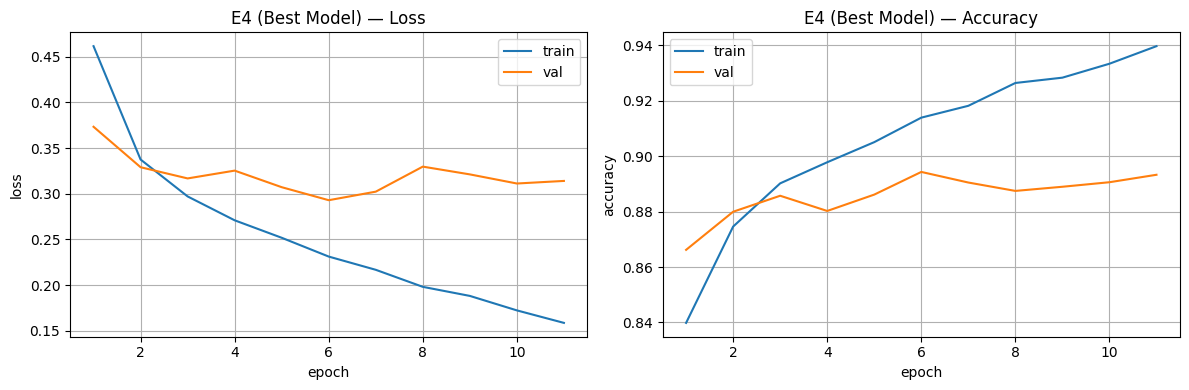

In [11]:
# График для E4 (лучшей модели) — сохраняем
os.makedirs("artifacts/figures", exist_ok=True)
plot_history(history_e4, title="E4 (Best Model)", save_path="artifacts/figures/curves_best.png")

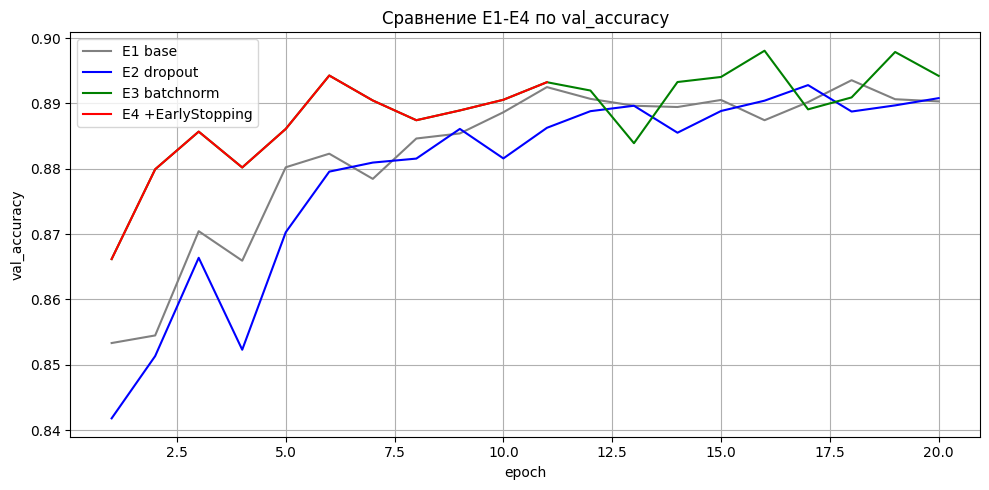

Saved → artifacts/figures/compare_E1_E4.png


In [12]:
# Сравнительный график E1-E4 по val_accuracy
plt.figure(figsize=(10, 5))
for label, hist, color in [
    ("E1 base",    history_e1, "gray"),
    ("E2 dropout", history_e2, "blue"),
    ("E3 batchnorm", history_e3, "green"),
    ("E4 +EarlyStopping", history_e4, "red"),
]:
    plt.plot(np.arange(1, len(hist["val_acc"]) + 1), hist["val_acc"], label=label, color=color)
plt.xlabel("epoch"); plt.ylabel("val_accuracy")
plt.title("Сравнение E1-E4 по val_accuracy")
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig("artifacts/figures/compare_E1_E4.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → artifacts/figures/compare_E1_E4.png")

## 5. Часть B (S09): LR, оптимизаторы, weight decay (O1–O3)

### O1 — Adam, LR слишком большой (1e-1)

In [13]:
EPOCHS_O = 8

set_seed(SEED)
model_o1 = MLP(**best_config_kwargs).to(device)
optim_o1 = optim.Adam(model_o1.parameters(), lr=1e-1)

history_o1 = fit(
    model_o1, train_loader, val_loader, optim_o1, criterion, device,
    epochs=EPOCHS_O, desc="O1-lr_too_big"
)

best_val_acc_o1  = max(history_o1["val_acc"])
runs.append({
    "experiment_id": "O1",
    "dataset": DATASET_NAME,
    "seed": SEED,
    "model_summary": e4_summary,
    "optimizer": "Adam",
    "lr": 1e-1,
    "momentum": "",
    "weight_decay": 0,
    "epochs_trained": EPOCHS_O,
    "best_val_accuracy": round(best_val_acc_o1, 4),
    "best_val_loss": round(min(history_o1["val_loss"]), 4),
})
print(f"O1 best val_acc={best_val_acc_o1:.4f}")

[O1-lr_too_big] epoch 01/8 | train loss=0.5890 acc=0.7858 | val loss=0.4612 acc=0.8341
[O1-lr_too_big] epoch 02/8 | train loss=0.4338 acc=0.8438 | val loss=0.4199 acc=0.8555
[O1-lr_too_big] epoch 03/8 | train loss=0.3894 acc=0.8600 | val loss=0.3972 acc=0.8630
[O1-lr_too_big] epoch 04/8 | train loss=0.3641 acc=0.8683 | val loss=0.3978 acc=0.8588
[O1-lr_too_big] epoch 05/8 | train loss=0.3540 acc=0.8730 | val loss=0.3701 acc=0.8715
[O1-lr_too_big] epoch 06/8 | train loss=0.3226 acc=0.8818 | val loss=0.3475 acc=0.8748
[O1-lr_too_big] epoch 07/8 | train loss=0.3197 acc=0.8831 | val loss=0.4055 acc=0.8614
[O1-lr_too_big] epoch 08/8 | train loss=0.2970 acc=0.8907 | val loss=0.3865 acc=0.8747
O1 best val_acc=0.8748


### O2 — Adam, LR слишком маленький (1e-5)

In [14]:
set_seed(SEED)
model_o2 = MLP(**best_config_kwargs).to(device)
optim_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)

history_o2 = fit(
    model_o2, train_loader, val_loader, optim_o2, criterion, device,
    epochs=EPOCHS_O, desc="O2-lr_too_small"
)

best_val_acc_o2  = max(history_o2["val_acc"])
runs.append({
    "experiment_id": "O2",
    "dataset": DATASET_NAME,
    "seed": SEED,
    "model_summary": e4_summary,
    "optimizer": "Adam",
    "lr": 1e-5,
    "momentum": "",
    "weight_decay": 0,
    "epochs_trained": EPOCHS_O,
    "best_val_accuracy": round(best_val_acc_o2, 4),
    "best_val_loss": round(min(history_o2["val_loss"]), 4),
})
print(f"O2 best val_acc={best_val_acc_o2:.4f}")

[O2-lr_too_small] epoch 01/8 | train loss=1.3557 acc=0.6610 | val loss=0.9952 acc=0.7647
[O2-lr_too_small] epoch 02/8 | train loss=0.8827 acc=0.7872 | val loss=0.7839 acc=0.8057
[O2-lr_too_small] epoch 03/8 | train loss=0.7304 acc=0.8171 | val loss=0.6749 acc=0.8282
[O2-lr_too_small] epoch 04/8 | train loss=0.6385 acc=0.8365 | val loss=0.6027 acc=0.8400
[O2-lr_too_small] epoch 05/8 | train loss=0.5768 acc=0.8452 | val loss=0.5505 acc=0.8489
[O2-lr_too_small] epoch 06/8 | train loss=0.5297 acc=0.8551 | val loss=0.5112 acc=0.8563
[O2-lr_too_small] epoch 07/8 | train loss=0.4914 acc=0.8621 | val loss=0.4791 acc=0.8617
[O2-lr_too_small] epoch 08/8 | train loss=0.4585 acc=0.8695 | val loss=0.4523 acc=0.8681
O2 best val_acc=0.8681


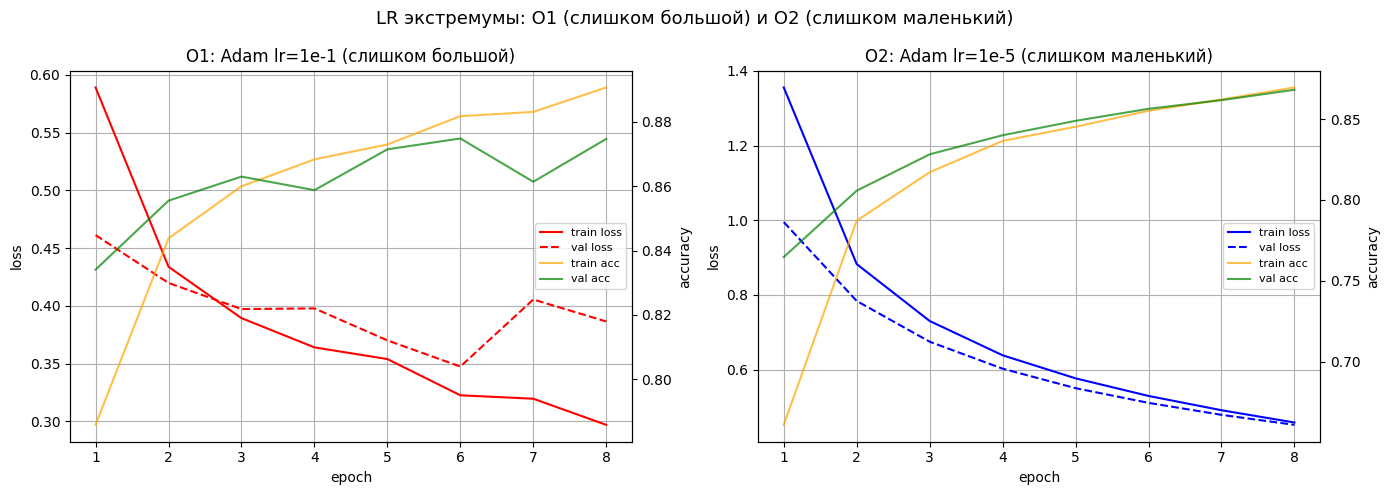

Saved → artifacts/figures/curves_lr_extremes.png


In [15]:
# График O1 и O2 — «плохие» learning rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, hist, title, color in [
    (axes[0], history_o1, "O1: Adam lr=1e-1 (слишком большой)", "red"),
    (axes[1], history_o2, "O2: Adam lr=1e-5 (слишком маленький)", "blue"),
]:
    epochs_range = np.arange(1, len(hist["train_loss"]) + 1)
    ax.plot(epochs_range, hist["train_loss"], label="train loss", color=color)
    ax.plot(epochs_range, hist["val_loss"],   label="val loss",   color=color, linestyle="--")
    ax2 = ax.twinx()
    ax2.plot(epochs_range, hist["train_acc"], label="train acc", color="orange", alpha=0.7)
    ax2.plot(epochs_range, hist["val_acc"],   label="val acc",   color="green",  alpha=0.7)
    ax2.set_ylabel("accuracy")
    ax.set_title(title); ax.set_xlabel("epoch"); ax.set_ylabel("loss")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=8)
    ax.grid(True)

plt.suptitle("LR экстремумы: O1 (слишком большой) и O2 (слишком маленький)", fontsize=13)
plt.tight_layout()
plt.savefig("artifacts/figures/curves_lr_extremes.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → artifacts/figures/curves_lr_extremes.png")

### O3 — SGD + momentum + weight decay

In [16]:
LR_SGD      = 1e-2
MOMENTUM    = 0.9
WEIGHT_DECAY = 1e-4
EPOCHS_O3   = 15

set_seed(SEED)
model_o3 = MLP(**best_config_kwargs).to(device)
optim_o3 = optim.SGD(
    model_o3.parameters(),
    lr=LR_SGD,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

history_o3 = fit(
    model_o3, train_loader, val_loader, optim_o3, criterion, device,
    epochs=EPOCHS_O3, desc="O3-SGD+momentum+wd"
)

best_val_acc_o3  = max(history_o3["val_acc"])
runs.append({
    "experiment_id": "O3",
    "dataset": DATASET_NAME,
    "seed": SEED,
    "model_summary": e4_summary,
    "optimizer": "SGD",
    "lr": LR_SGD,
    "momentum": MOMENTUM,
    "weight_decay": WEIGHT_DECAY,
    "epochs_trained": EPOCHS_O3,
    "best_val_accuracy": round(best_val_acc_o3, 4),
    "best_val_loss": round(min(history_o3["val_loss"]), 4),
})
print(f"O3 best val_acc={best_val_acc_o3:.4f}")

[O3-SGD+momentum+wd] epoch 01/15 | train loss=0.4779 acc=0.8341 | val loss=0.3609 acc=0.8689
[O3-SGD+momentum+wd] epoch 02/15 | train loss=0.3273 acc=0.8793 | val loss=0.3289 acc=0.8806
[O3-SGD+momentum+wd] epoch 03/15 | train loss=0.2860 acc=0.8933 | val loss=0.3185 acc=0.8843
[O3-SGD+momentum+wd] epoch 04/15 | train loss=0.2577 acc=0.9044 | val loss=0.3170 acc=0.8872
[O3-SGD+momentum+wd] epoch 05/15 | train loss=0.2375 acc=0.9115 | val loss=0.3163 acc=0.8815
[O3-SGD+momentum+wd] epoch 06/15 | train loss=0.2161 acc=0.9196 | val loss=0.2998 acc=0.8910
[O3-SGD+momentum+wd] epoch 07/15 | train loss=0.2009 acc=0.9257 | val loss=0.2912 acc=0.8938
[O3-SGD+momentum+wd] epoch 08/15 | train loss=0.1823 acc=0.9320 | val loss=0.3144 acc=0.8888
[O3-SGD+momentum+wd] epoch 09/15 | train loss=0.1692 acc=0.9377 | val loss=0.3192 acc=0.8912
[O3-SGD+momentum+wd] epoch 10/15 | train loss=0.1581 acc=0.9410 | val loss=0.3119 acc=0.8898
[O3-SGD+momentum+wd] epoch 11/15 | train loss=0.1452 acc=0.9452 | val 

## 6. Финальная оценка лучшей модели (E4) на TEST

> Test используется **один раз** — только здесь!

In [17]:
test_loss, test_acc = evaluate(model_e4, test_loader, criterion, device)
print(f"=== Финальный результат E4 на TEST ===")
print(f"test_loss = {test_loss:.4f}")
print(f"test_acc  = {test_acc:.4f}")

=== Финальный результат E4 на TEST ===
test_loss = 0.3167
test_acc  = 0.8885


## 7. Сохранение артефактов

In [18]:
os.makedirs("artifacts", exist_ok=True)

# 1) runs.csv
df = pd.DataFrame(runs)
df.to_csv("artifacts/runs.csv", index=False)
print("Saved → artifacts/runs.csv")
display(df)

Saved → artifacts/runs.csv


,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
0,E1,FashionMNIST,42,"MLP(512, 256, 128)/ReLU/drop=0/BN=False",Adam,0.00100,,0.0000,20,0.8936,0.3143
1,E2,FashionMNIST,42,"MLP(512, 256, 128)/ReLU/drop=0.3/BN=False",Adam,0.00100,,0.0000,20,0.8928,0.3088
2,E3,FashionMNIST,42,"MLP(512, 256, 128)/ReLU/drop=0/BN=True",Adam,0.00100,,0.0000,20,0.8981,0.2930
3,E4,FashionMNIST,42,"MLP(512, 256, 128)/ReLU/drop=0/BN=True+ES(pati...",Adam,0.00100,,0.0000,11,0.8943,0.2930
4,O1,FashionMNIST,42,"MLP(512, 256, 128)/ReLU/drop=0/BN=True",Adam,0.10000,,0.0000,8,0.8748,0.3475
5,O2,FashionMNIST,42,"MLP(512, 256, 128)/ReLU/drop=0/BN=True",Adam,0.00001,,0.0000,8,0.8681,0.4523
6,O3,FashionMNIST,42,"MLP(512, 256, 128)/ReLU/drop=0/BN=True",SGD,0.01000,0.9,0.0001,15,0.8938,0.2912


In [19]:
# 2) best_model.pt
torch.save(model_e4.state_dict(), "artifacts/best_model.pt")
print("Saved → artifacts/best_model.pt")

# 3) best_config.json
best_config = {
    "dataset": DATASET_NAME,
    "seed": SEED,
    "input_dim": 28 * 28,
    "hidden_dims": list(HIDDEN_DIMS),
    "num_classes": NUM_CLASSES,
    "dropout_p": best_config_kwargs["dropout_p"],
    "use_batchnorm": best_config_kwargs["use_batchnorm"],
    "activation": "ReLU",
    "optimizer": "Adam",
    "lr": LR_BASE,
    "weight_decay": 0,
    "early_stopping_patience": 5,
    "batch_size": BATCH_SIZE,
    "epochs_trained": stopped_at,
    "best_val_accuracy": round(best_val_acc_e4, 4),
    "test_accuracy": round(test_acc, 4),
}
with open("artifacts/best_config.json", "w") as f:
    json.dump(best_config, f, indent=2)
print("Saved → artifacts/best_config.json")
print(json.dumps(best_config, indent=2))

Saved → artifacts/best_model.pt
Saved → artifacts/best_config.json
{
  "dataset": "FashionMNIST",
  "seed": 42,
  "input_dim": 784,
  "hidden_dims": [
    512,
    256,
    128
  ],
  "num_classes": 10,
  "dropout_p": 0.0,
  "use_batchnorm": true,
  "activation": "ReLU",
  "optimizer": "Adam",
  "lr": 0.001,
  "weight_decay": 0,
  "early_stopping_patience": 5,
  "batch_size": 128,
  "epochs_trained": 11,
  "best_val_accuracy": 0.8943,
  "test_accuracy": 0.8885
}


## 8. Итоговая сводка

In [20]:
print("=" * 55)
print("          ИТОГОВАЯ СВОДКА ЭКСПЕРИМЕНТОВ")
print("=" * 55)
for r in runs:
    print(f"  {r['experiment_id']:3s}  val_acc={r['best_val_accuracy']:.4f}  "
          f"opt={r['optimizer']}  lr={r['lr']}  "
          f"wd={r['weight_decay']}  epochs={r['epochs_trained']}")
print("-" * 55)
print(f"  Лучшая модель: E4")
print(f"  best val_acc  = {best_val_acc_e4:.4f}")
print(f"  final test_acc = {test_acc:.4f}")
print("=" * 55)

          ИТОГОВАЯ СВОДКА ЭКСПЕРИМЕНТОВ
  E1   val_acc=0.8936  opt=Adam  lr=0.001  wd=0  epochs=20
  E2   val_acc=0.8928  opt=Adam  lr=0.001  wd=0  epochs=20
  E3   val_acc=0.8981  opt=Adam  lr=0.001  wd=0  epochs=20
  E4   val_acc=0.8943  opt=Adam  lr=0.001  wd=0  epochs=11
  O1   val_acc=0.8748  opt=Adam  lr=0.1  wd=0  epochs=8
  O2   val_acc=0.8681  opt=Adam  lr=1e-05  wd=0  epochs=8
  O3   val_acc=0.8938  opt=SGD  lr=0.01  wd=0.0001  epochs=15
-------------------------------------------------------
  Лучшая модель: E4
  best val_acc  = 0.8943
  final test_acc = 0.8885
